#Universidad de Buenos Aires - FIUBA - LSE
#Visión por computadora - TP2
#Cohorte 25 - 3er bimestre 2026

**Integrantes:**

a2413, César Hernán Ruggeri

a2512, Armando Tomás Civini

a2521, Andrea Tatiana Duran

a2525, Pablo David Gorosito

a2542, Federico Tombesi

Clonamos repositorio donde están las imágenes

In [ ]:
import cv2

# Cambiá el nombre del archivo por el que tengas dentro de la carpeta 'video'
video_path = 'Video/tu_video.mp4'

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error al abrir el video")

In [ ]:
!git clone https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/vision_computadora_I.git

Cloning into 'vision_computadora_I'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 1358 (delta 20), reused 14 (delta 13), pack-reused 1299 (from 4)
Receiving objects: 100% (1358/1358), 306.56 MiB | 22.91 MiB/s, done.
Resolving deltas: 100% (543/543), done.


In [ ]:
import os
os.listdir("vision_computadora_I")  # ver contenido del repo

['.git', 'Diapositivas', 'Material_TPs', 'Articulos', 'Codigo', 'readme.md']

In [ ]:
import glob

video_path = glob.glob("/content/vision_computadora_I/Material_TPs/TP2/*")
video_path

['/content/vision_computadora_I/Material_TPs/TP2/focus_video.mov']

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def to_grayscale(image):
    """Convierte a escala de grises si la imagen viene en color."""
    if image.ndim == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image

def compute_fm(image, threshold_ratio=1/1000):
    """
    Calcula la métrica FM (Frequency Domain Blur Measure) del paper.
    Sirve tanto para un frame completo como para una ROI (recorte).
    """
    gray = to_grayscale(image).astype(np.float64)
    M, N = gray.shape

    # Paso 1: Transformada de Fourier 2D
    F = np.fft.fft2(gray)

    # Paso 2: Centrar el espectro (origen al centro)
    Fc = np.fft.fftshift(F)

    # Paso 3: Magnitud del espectro centrado
    AF = np.abs(Fc)

    # Paso 4: Máximo valor de frecuencia
    Mmax = AF.max()

    # Paso 5: Umbral y conteo de componentes de alta frecuencia
    thres = Mmax * threshold_ratio
    TH = int(np.sum(AF > thres))

    # Paso 6: Métrica final
    FM = TH / (M * N)
    return FM


def mostrar_imagen(imagen, titulo=''):
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
    plt.show()

def get_centered_roi_coords(shape, area_fraction):
    """Calcula los límites de un ROI centrado, con área = area_fraction del total."""
    M, N = shape[:2]
    scale = np.sqrt(area_fraction)   # escala lineal, para que el ÁREA sea la fracción pedida
    roi_h = max(1, int(round(M * scale)))
    roi_w = max(1, int(round(N * scale)))
    y0 = (M - roi_h) // 2
    x0 = (N - roi_w) // 2
    return y0, y0 + roi_h, x0, x0 + roi_w

def crop_centered_roi(image, area_fraction):
    y0, y1, x0, x1 = get_centered_roi_coords(image.shape, area_fraction)
    return image[y0:y1, x0:x1]

In [ ]:
cap = cv2.VideoCapture(video_path[0])
fps = cap.get(cv2.CAP_PROP_FPS)
print("FPS:", fps)

FPS: 29.97002997002997


In [ ]:
def analizar_video(video_path, roi_fractions=(0.05, 0.10)):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"No se pudo abrir el video: {video_path}")

    fm_full = []
    fm_rois = {f: [] for f in roi_fractions}

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # --- Frame completo ---
        res_full = compute_fm(frame)
        fm_full.append(res_full)

        # --- ROIs centrados ---
        for frac in roi_fractions:
            roi = crop_centered_roi(frame, frac)
            res_roi = compute_fm(roi)
            fm_rois[frac].append(res_roi)

        frame_idx += 1

    cap.release()
    return np.array(fm_full), {f: np.array(v) for f, v in fm_rois.items()}


def graficar_curvas(fm_full, fm_rois, fps=None):
    x = np.arange(len(fm_full))
    if fps:
        x = x / fps  # eje en segundos en vez de nº de frame

    plt.figure(figsize=(11, 6))

    # Curva del frame completo
    plt.plot(x, fm_full, label="Frame completo", linewidth=1.5)
    idx_max_full = np.argmax(fm_full)
    plt.scatter(
        x[idx_max_full],
        fm_full[idx_max_full],
        color="red",
        zorder=5,
        label=f"Máx. enfoque (frame completo) = frame {idx_max_full}"
    )

    # Curvas de las ROIs
    colors = ["green", "orange"]

    for (frac, valores), c in zip(fm_rois.items(), colors):
        porcentaje = int(frac * 100)

        plt.plot(
            x,
            valores,
            label=f"ROI centrado {porcentaje}%",
            linewidth=1.2,
            color=c
        )

        idx_max_roi = np.argmax(valores)

        plt.scatter(
            x[idx_max_roi],
            valores[idx_max_roi],
            color=c,
            marker="x",
            s=90,
            zorder=5,
            label=f"Máx. ROI {porcentaje}% = frame {idx_max_roi}"
        )

    plt.xlabel("Tiempo (s)" if fps else "Número de frame")
    plt.ylabel("FM (métrica de nitidez)")
    plt.title("Evolución de la métrica FM a lo largo del video")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("curvas_fm.png", dpi=150)
    plt.show()

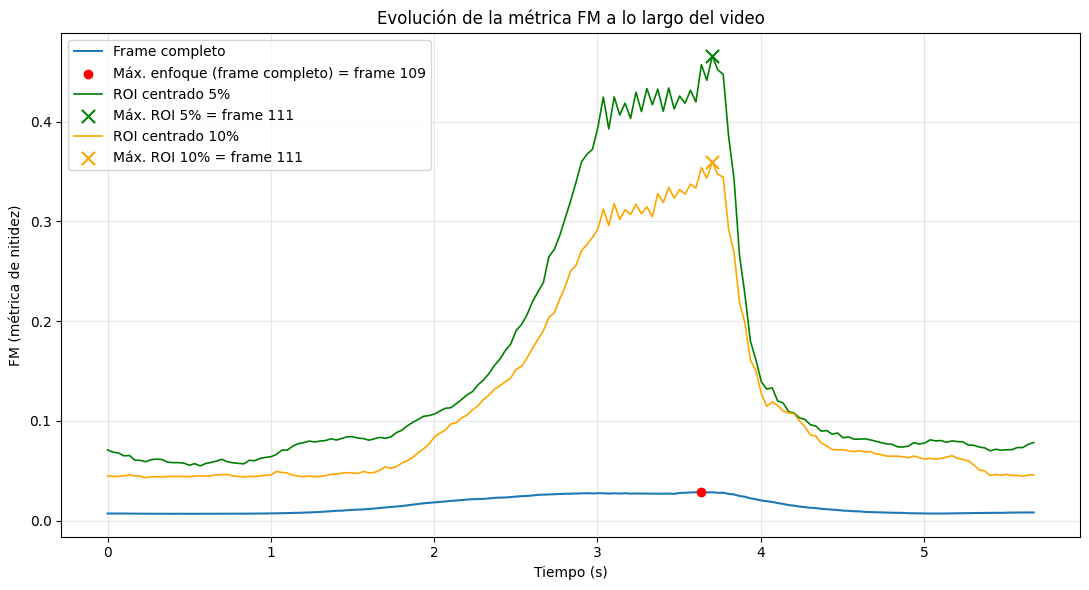

In [ ]:
fm_full, fm_rois = analizar_video(video_path[0])
graficar_curvas(fm_full, fm_rois, fps=fps)

In [ ]:
def gauss_suav_vid(cap):
  frames = []
  suav_frames = []
  while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)
    suav_frames.append(cv2.GaussianBlur(frame, ksize=(5, 5), sigmaX=1.5,  sigmaY=1.5))
  return frames, suav_frames

def unsharp_masking(cap):
  frames, suav_frames = gauss_suav_vid(cap)
  for i in range(len(frames)):
    m = cv2.subtract(frames[i], suav_frames[i])
    frames[i] = cv2.add(frames[i], m)
  return frames

In [ ]:
cap = cv2.VideoCapture(video_path[0])
frames = unsharp_masking(cap)

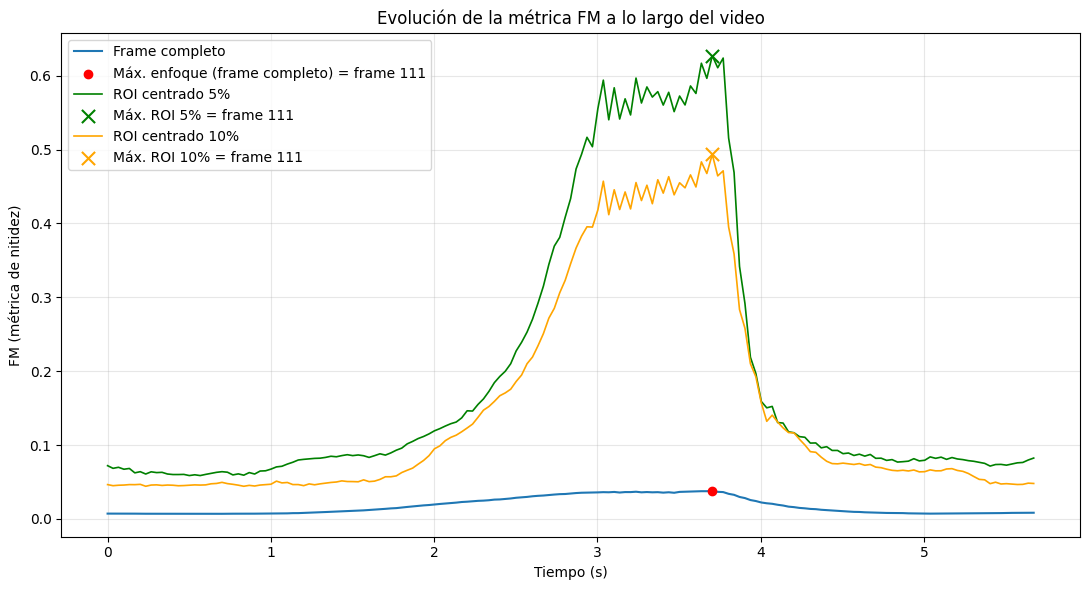

In [ ]:
roi_fractions = (0.05, 0.10)
fm_full = []
fm_rois = {f: [] for f in roi_fractions}

for frame in frames:
    # --- Frame completo ---
    res_full = compute_fm(frame)
    fm_full.append(res_full)

    # --- ROIs centrados ---
    for frac in roi_fractions:
        roi = crop_centered_roi(frame, frac)
        res_roi = compute_fm(roi)
        fm_rois[frac].append(res_roi)

graficar_curvas(fm_full, fm_rois, fps=fps)

## Punto extra: matriz espacial de enfoque y unsharp masking

En esta sección se construye una matriz espacial de enfoque sobre el frame identificado automáticamente como el de mayor nitidez. Para ello, el frame se divide en pequeñas regiones y se calcula la métrica FM en cada una. Luego, la matriz obtenida se interpola y se superpone sobre la imagen original. Finalmente, se aplica unsharp masking para analizar si aumenta la región detectada como enfocada.



In [ ]:
# Detectar automáticamente el frame de máximo enfoque
idx_max_enfoque = int(np.argmax(fm_full))

# Abrir nuevamente el video
cap = cv2.VideoCapture(video_path[0])

if not cap.isOpened():
    raise IOError(f"No se pudo abrir el video: {video_path[0]}")

# Posicionarse en el frame de máximo enfoque
cap.set(cv2.CAP_PROP_POS_FRAMES, idx_max_enfoque)

ret, frame_max_enfoque = cap.read()
cap.release()

if not ret:
    raise ValueError(
        f"No se pudo leer el frame {idx_max_enfoque}"
    )

print(
    f"Frame seleccionado automáticamente: "
    f"{idx_max_enfoque}"
)

Frame seleccionado automáticamente: 111


In [ ]:
def calcular_matriz_enfoque(
    frame,
    filas=12,
    columnas=16,
    threshold_ratio=1 / 1000
):
    """
    Divide el frame en una grilla y calcula la métrica FM
    en cada región.

    Retorna
    -------
    matriz_enfoque : numpy.ndarray
        Matriz de tamaño filas x columnas con un valor FM
        para cada región espacial.
    """

    alto, ancho = frame.shape[:2]

    alto_celda = alto // filas
    ancho_celda = ancho // columnas

    matriz_enfoque = np.zeros(
        (filas, columnas),
        dtype=np.float32
    )

    for fila in range(filas):
        for columna in range(columnas):

            y0 = fila * alto_celda
            x0 = columna * ancho_celda

            # En la última fila y columna se incluye
            # cualquier píxel restante
            y1 = alto if fila == filas - 1 else (fila + 1) * alto_celda
            x1 = ancho if columna == columnas - 1 else (columna + 1) * ancho_celda

            region = frame[y0:y1, x0:x1]

            matriz_enfoque[fila, columna] = compute_fm(
                region,
                threshold_ratio=threshold_ratio
            )

    return matriz_enfoque

In [ ]:
matriz_enfoque_original = calcular_matriz_enfoque(
    frame_max_enfoque,
    filas=12,
    columnas=16
)

print(
    "Dimensiones de la matriz de enfoque:",
    matriz_enfoque_original.shape
)

print(
    "Valor mínimo de FM:",
    matriz_enfoque_original.min()
)

print(
    "Valor máximo de FM:",
    matriz_enfoque_original.max()
)

Dimensiones de la matriz de enfoque: (12, 16)
Valor mínimo de FM: 0.050833333
Valor máximo de FM: 0.955


In [ ]:
def superponer_matriz_enfoque(
    frame,
    matriz_enfoque,
    alpha=0.45
):
    """
    Interpola la matriz de enfoque al tamaño del frame
    y la superpone como mapa de calor.

    Retorna
    -------
    superposicion : numpy.ndarray
        Frame BGR con el mapa de enfoque superpuesto.

    mapa_normalizado : numpy.ndarray
        Matriz normalizada e interpolada al tamaño del frame.
    """

    alto, ancho = frame.shape[:2]

    # Normalizar la matriz entre 0 y 255
    mapa_normalizado = cv2.normalize(
        matriz_enfoque,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Ampliar la matriz al tamaño completo del frame
    mapa_redimensionado = cv2.resize(
        mapa_normalizado,
        (ancho, alto),
        interpolation=cv2.INTER_CUBIC
    )

    # Convertir a mapa de calor
    mapa_color = cv2.applyColorMap(
        mapa_redimensionado,
        cv2.COLORMAP_JET
    )

    # Superponer el mapa sobre el frame
    superposicion = cv2.addWeighted(
        frame,
        1.0 - alpha,
        mapa_color,
        alpha,
        0
    )

    return superposicion, mapa_redimensionado

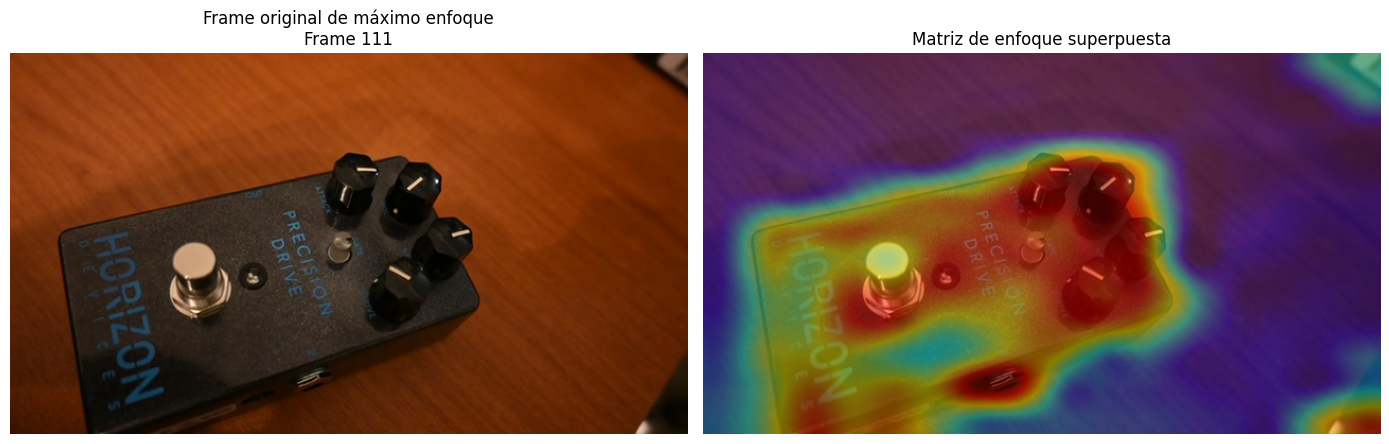

In [ ]:
frame_con_matriz, mapa_enfoque_original = superponer_matriz_enfoque(
    frame_max_enfoque,
    matriz_enfoque_original,
    alpha=0.45
)

# Convertir BGR a RGB para Matplotlib
frame_original_rgb = cv2.cvtColor(
    frame_max_enfoque,
    cv2.COLOR_BGR2RGB
)

frame_con_matriz_rgb = cv2.cvtColor(
    frame_con_matriz,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(frame_original_rgb)
plt.title(
    f"Frame original de máximo enfoque\n"
    f"Frame {idx_max_enfoque}"
)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(frame_con_matriz_rgb)
plt.title("Matriz de enfoque superpuesta")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def aplicar_unsharp_mask(
    frame,
    sigma=1.5,
    amount=1.0
):
    """
    Aplica unsharp masking mediante una combinación ponderada
    entre el frame original y su versión suavizada.

    Parámetros
    ----------
    frame : numpy.ndarray
        Imagen BGR original.

    sigma : float
        Desviación estándar del filtro gaussiano.

    amount : float
        Intensidad del realce.

    Retorna
    -------
    frame_realzado : numpy.ndarray
        Imagen realzada.
    """

    frame_suavizado = cv2.GaussianBlur(
        frame,
        ksize=(0, 0),
        sigmaX=sigma,
        sigmaY=sigma
    )

    frame_realzado = cv2.addWeighted(
        frame,
        1.0 + amount,
        frame_suavizado,
        -amount,
        0
    )

    return frame_realzado

In [ ]:
frame_realzado = aplicar_unsharp_mask(
    frame_max_enfoque,
    sigma=1.5,
    amount=1.0
)

In [ ]:
matriz_enfoque_realzada = calcular_matriz_enfoque(
    frame_realzado,
    filas=12,
    columnas=16
)

frame_realzado_con_matriz, mapa_enfoque_realzado = (
    superponer_matriz_enfoque(
        frame_realzado,
        matriz_enfoque_realzada,
        alpha=0.45
    )
)

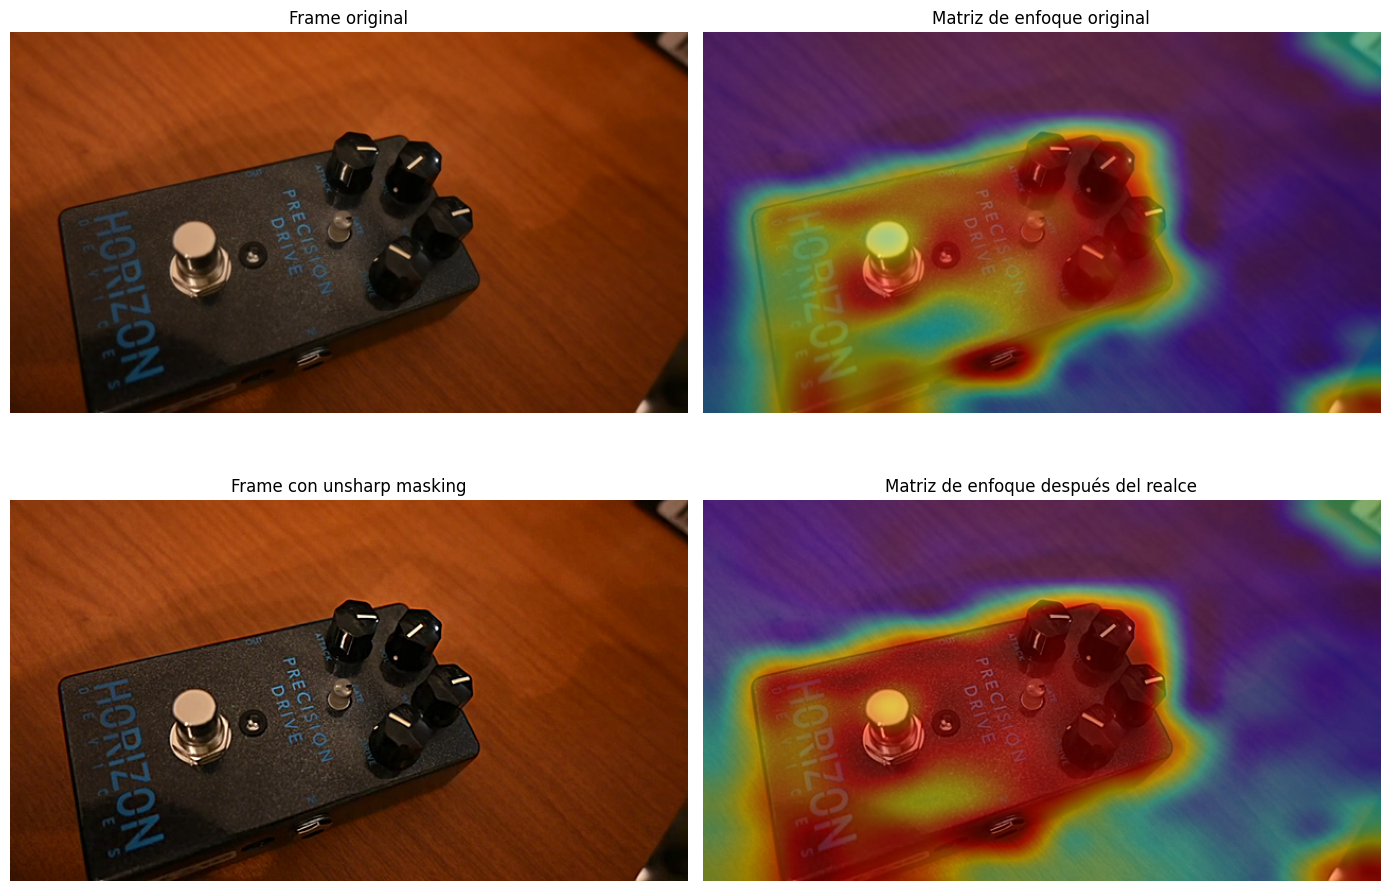

In [ ]:
frame_realzado_rgb = cv2.cvtColor(
    frame_realzado,
    cv2.COLOR_BGR2RGB
)

frame_realzado_con_matriz_rgb = cv2.cvtColor(
    frame_realzado_con_matriz,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(frame_original_rgb)
plt.title("Frame original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(frame_con_matriz_rgb)
plt.title("Matriz de enfoque original")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(frame_realzado_rgb)
plt.title("Frame con unsharp masking")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(frame_realzado_con_matriz_rgb)
plt.title("Matriz de enfoque después del realce")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def calcular_proporcion_zona_enfocada(
    matriz_enfoque,
    umbral_relativo=0.70
):
    """
    Calcula la proporción de celdas cuya métrica FM
    es igual o superior a un porcentaje del máximo.

    Por ejemplo, 0.70 considera enfocadas las celdas
    que alcanzan al menos el 70% del máximo de la matriz.
    """

    valor_maximo = matriz_enfoque.max()

    if valor_maximo == 0:
        return 0.0

    umbral = umbral_relativo * valor_maximo

    mascara_enfoque = matriz_enfoque >= umbral

    proporcion = np.mean(mascara_enfoque)

    return proporcion

In [ ]:
proporcion_original = calcular_proporcion_zona_enfocada(
    matriz_enfoque_original,
    umbral_relativo=0.70
)

proporcion_realzada = calcular_proporcion_zona_enfocada(
    matriz_enfoque_realzada,
    umbral_relativo=0.70
)

print(
    f"Zona enfocada original: "
    f"{proporcion_original * 100:.2f}%"
)

print(
    f"Zona enfocada después del unsharp masking: "
    f"{proporcion_realzada * 100:.2f}%"
)

diferencia = (
    proporcion_realzada -
    proporcion_original
)

print(
    f"Diferencia: "
    f"{diferencia * 100:.2f} puntos porcentuales"
)

Zona enfocada original: 21.88%
Zona enfocada después del unsharp masking: 35.42%
Diferencia: 13.54 puntos porcentuales


La matriz espacial de enfoque permitió identificar las regiones del frame con mayor respuesta de la métrica FM. El mapa superpuesto muestra que las zonas de mayor nitidez se concentran principalmente sobre los bordes y detalles del objeto.

Después de aplicar unsharp masking, se observa un incremento de la respuesta frecuencial en distintas regiones del frame. Esto indica una expansión de la zona detectada como enfocada por la métrica utilizada.

No obstante, el resultado debe interpretarse como un aumento de la nitidez perceptual y de las componentes de alta frecuencia. El filtro no modifica el enfoque óptico original ni recupera detalles que se hayan perdido por desenfoque.

## PUNTO 2: IMPLEMENTACIÓN DE MÉTRICA DE ENFOQUE (Modified Laplacian - Gray-Level Variance)


En SFF, sin embargo, es necesario estimar la profundidad de cada píxel, y el operador de medida de enfoque se aplica mediante una pequeña ventana local.

## Selección de algoritmos del apéndice para el análisis

Analizamos dos algoritmos del apéndice, seleccionando dos de los operadores más representativos y de mejor desempeño reportados en el estudio:

---

### Algoritmo 1: LAP2 – Modified laplacian [Apéndice A.18]

* **Basados en Laplaciano (LAP)**: detectan bordes y cambios rápidos de intensidad mediante la segunda derivada o Laplaciano. En el paper figura como uno de los operadores con mejor rendimiento global (*overall performance*) en condiciones normales de captura.
* **Fórmula:**

$$\Delta_m I = |I * L_X| + |I * L_Y| \quad \text{con } L_X = [1, -2, 1] \text{ y } L_Y = L_X^T$$

$$\text{FM}(x,y) = \sum_{(i,j) \in \Omega(x,y)} \Delta_m I(i,j)$$

---

### Algoritmo 2: STA3 – Gray-Level variance [Apéndice A.24]

* **Basados en Estadística (STA)**: utilizan descriptores de textura e información estadística de la imagen. Destaca en el paper por su alta robustez ante el ruido de imagen, superando a los operadores basados en derivadas cuando el nivel de ruido aumenta.
* **Fórmula:**

$$\text{FM}(x,y) = \sum_{(i,j) \in \Omega(x,y)} (I(i,j) - \mu)^2$$

$\mu$ como valor medio de gris en la ventana local $\Omega(x,y)$.

In [ ]:
def convertir_a_escala_de_grises(imagen: np.ndarray) -> np.ndarray:
    """Convierte la imagen directamente a escala de grises."""
    return cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY).astype(np.float64)

def obtener_coordenadas_roi_centrada(forma_imagen: tuple, fraccion_area: float):
    """
    Calcula los límites (y0, y1, x0, x1) para recortar una Región de Interés (ROI)
    centrada en la imagen, según la proporción de área deseada.
    """
    alto, ancho = forma_imagen[:2]
    escala = np.sqrt(fraccion_area)

    alto_roi = max(1, int(round(alto * escala)))
    ancho_roi = max(1, int(round(ancho * escala)))

    y0 = (alto - alto_roi) // 2
    x0 = (ancho - ancho_roi) // 2

    return y0, y0 + alto_roi, x0, x0 + ancho_roi

def recortar_roi_centrada(imagen: np.ndarray, fraccion_area: float) -> np.ndarray:
    """Extraemos la región central (ROI) de la imagen."""
    y0, y1, x0, x1 = obtener_coordenadas_roi_centrada(imagen.shape, fraccion_area)
    return imagen[y0:y1, x0:x1]

def calcular_lap2(imagen: np.ndarray) -> float:
    """
    Calculamos la métrica de enfoque LAP2 (Laplaciano modificado / Modified laplacian).
    Mayor nitidez en la imagen, mayor valor de salida.
    """
    grises = convertir_a_escala_de_grises(imagen)

    mascara_x = np.array([[1, -2, 1]], dtype=np.float64)
    mascara_y = mascara_x.T

    derivada_x = cv2.filter2D(grises, cv2.CV_64F, mascara_x)
    derivada_y = cv2.filter2D(grises, cv2.CV_64F, mascara_y)

    magnitud_laplaciana = np.abs(derivada_x) + np.abs(derivada_y)
    return float(np.mean(magnitud_laplaciana))

def calcular_sta3(imagen: np.ndarray) -> float:
    """
    Calculamos la métrica de enfoque STA3 (Varianza de niveles de gris / Gray-level variance).
    Medimos la dispersión del contraste respecto a su brillo medio.
    """
    grises = convertir_a_escala_de_grises(imagen)
    return float(np.var(grises))

def analizar_video_multi_metricas(ruta_video: str, fracciones_roi=(0.05, 0.10)):
    """
    Leemos un archivo de video fotograma a fotograma. Calculamos las métricas de enfoque
    (LAP2 y STA3) para el fotograma completo y las ROIs centrales especificadas.
    """
    captura = cv2.VideoCapture(ruta_video)
    if not captura.isOpened():
        raise IOError(f"Error: No se pudo abrir el archivo de video: {ruta_video}")

    fps = captura.get(cv2.CAP_PROP_FPS)

    resultados = {
        'LAP2_completo': [],
        'STA3_completo': [],
        'LAP2_rois': {fraccion: [] for fraccion in fracciones_roi},
        'STA3_rois': {fraccion: [] for fraccion in fracciones_roi}
    }

    contador_cuadros = 0
    while True:
        exito, fotograma = captura.read()
        if not exito:
            break

        # 1. Medición sobre la imagen completa
        resultados['LAP2_completo'].append(calcular_lap2(fotograma))
        resultados['STA3_completo'].append(calcular_sta3(fotograma))

        # 2. Medición sobre las ROIs especificadas
        for fraccion in fracciones_roi:
            roi = recortar_roi_centrada(fotograma, fraccion)
            resultados['LAP2_rois'][fraccion].append(calcular_lap2(roi))
            resultados['STA3_rois'][fraccion].append(calcular_sta3(roi))

        contador_cuadros += 1

    captura.release()
    print(f"--> Procesamiento finalizado. Total de fotogramas analizados: {contador_cuadros}")
    return resultados, fps

In [ ]:
# Evaluación del video empleando la función estructurada
datos_enfoque, fps = analizar_video_multi_metricas(video_path[0], fracciones_roi=(0.05, 0.10))

--> Procesamiento finalizado. Total de fotogramas analizados: 171


In [ ]:
# Creación del vector temporal basado en fotogramas transcurridos y FPS
fotogramas = np.arange(len(datos_enfoque['LAP2_completo']))
tiempo_segundos = fotogramas / fps if fps > 0 else fotogramas

def obtener_maximo_enfoque(valores_metrica, vector_tiempo):
    """Retorna el índice, el instante de tiempo exacto y el valor pico alcanzado."""
    indice_maximo = int(np.argmax(valores_metrica))
    tiempo_maximo = float(vector_tiempo[indice_maximo])
    valor_maximo = float(valores_metrica[indice_maximo])
    return indice_maximo, tiempo_maximo, valor_maximo

# Imprimir resultados del punto con mayor enfoque
print("=" * 65)
print("  RESULTADOS DE DETECCIÓN AUTOMÁTICA DE MÁXIMO ENFOQUE")
print("=" * 65)

idx_lap_f, t_lap_f, _ = obtener_maximo_enfoque(datos_enfoque['LAP2_completo'], tiempo_segundos)
print(f"-> LAP2 (Fotograma Completo) : Fotograma {idx_lap_f:3d} | Tiempo: {t_lap_f:.2f} s")
for fraccion, valores in datos_enfoque['LAP2_rois'].items():
    i_r, t_r, _ = obtener_maximo_enfoque(valores, tiempo_segundos)
    print(f"-> LAP2 (ROI {int(fraccion*100):2d}%)        : Fotograma {i_r:3d} | Tiempo: {t_r:.2f} s")

print("-" * 65)

idx_sta_f, t_sta_f, _ = obtener_maximo_enfoque(datos_enfoque['STA3_completo'], tiempo_segundos)
print(f"-> STA3 (Fotograma Completo) : Fotograma {idx_sta_f:3d} | Tiempo: {t_sta_f:.2f} s")
for fraccion, valores in datos_enfoque['STA3_rois'].items():
    i_r, t_r, _ = obtener_maximo_enfoque(valores, tiempo_segundos)
    print(f"-> STA3 (ROI {int(fraccion*100):2d}%)        : Fotograma {i_r:3d} | Tiempo: {t_r:.2f} s")

print("=" * 65)

  RESULTADOS DE DETECCIÓN AUTOMÁTICA DE MÁXIMO ENFOQUE
-> LAP2 (Fotograma Completo) : Fotograma 111 | Tiempo: 3.70 s
-> LAP2 (ROI  5%)        : Fotograma 101 | Tiempo: 3.37 s
-> LAP2 (ROI 10%)        : Fotograma 111 | Tiempo: 3.70 s
-----------------------------------------------------------------
-> STA3 (Fotograma Completo) : Fotograma 113 | Tiempo: 3.77 s
-> STA3 (ROI  5%)        : Fotograma 113 | Tiempo: 3.77 s
-> STA3 (ROI 10%)        : Fotograma 113 | Tiempo: 3.77 s


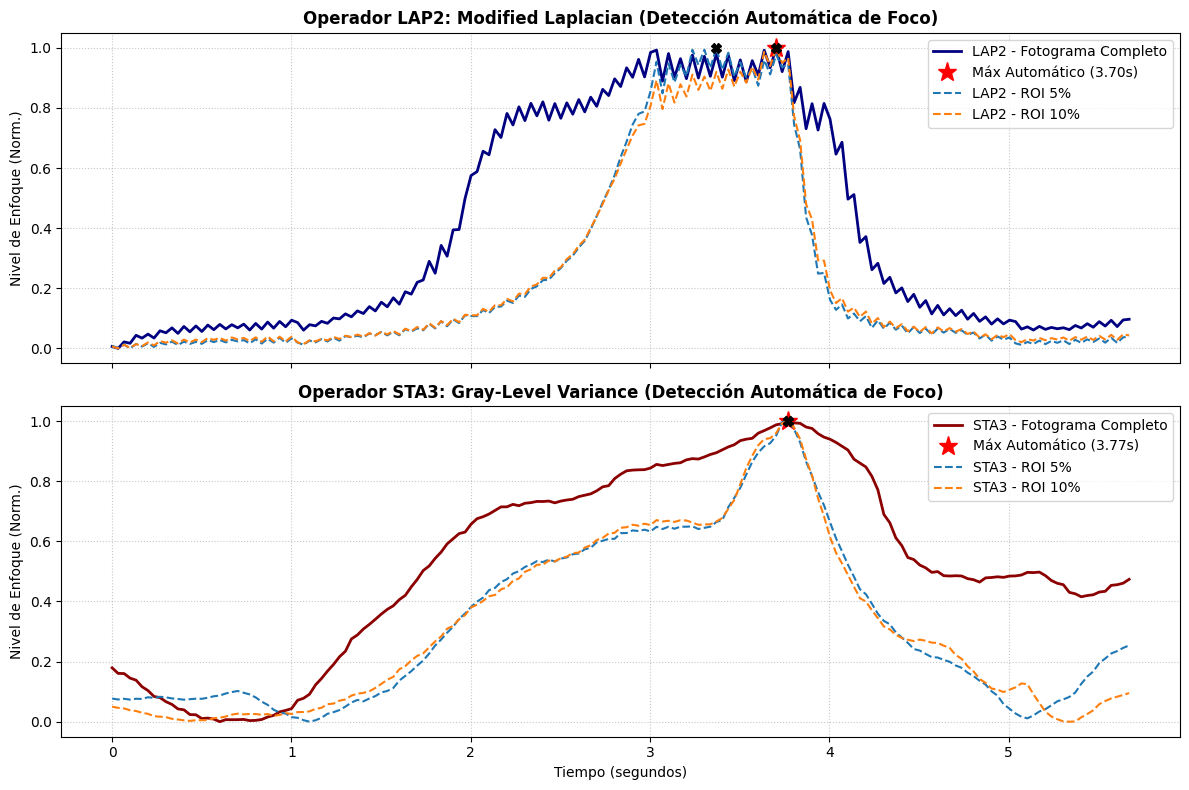

In [ ]:
figura, ejes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

def normalizar(arreglo):
    """Normalizamos el conjunto de datos en el rango [0, 1]."""
    arreglo = np.array(arreglo)
    rango = np.ptp(arreglo)
    return (arreglo - np.min(arreglo)) / (rango if rango > 0 else 1.0)

# 1. Gráfico del operador LAP2
lap_completo_norm = normalizar(datos_enfoque['LAP2_completo'])
ejes[0].plot(tiempo_segundos, lap_completo_norm, label='LAP2 - Fotograma Completo', color='navy', linewidth=2)
ejes[0].plot(t_lap_f, lap_completo_norm[idx_lap_f], 'r*', markersize=14, label=f'Máx Automático ({t_lap_f:.2f}s)')

for fraccion, valores in datos_enfoque['LAP2_rois'].items():
    val_norm = normalizar(valores)
    i_r, t_r, _ = obtener_maximo_enfoque(valores, tiempo_segundos)
    ejes[0].plot(tiempo_segundos, val_norm, label=f'LAP2 - ROI {int(fraccion*100)}%', linestyle='--')
    ejes[0].plot(t_r, val_norm[i_r], 'kX', markersize=7)

ejes[0].set_title('Operador LAP2: Modified Laplacian (Detección Automática de Foco)', fontsize=12, fontweight='bold')
ejes[0].set_ylabel('Nivel de Enfoque (Norm.)')
ejes[0].grid(True, linestyle=':', alpha=0.7)
ejes[0].legend(loc='upper right')

# 2. Gráfico del operador STA3
sta_completo_norm = normalizar(datos_enfoque['STA3_completo'])
ejes[1].plot(tiempo_segundos, sta_completo_norm, label='STA3 - Fotograma Completo', color='darkred', linewidth=2)
ejes[1].plot(t_sta_f, sta_completo_norm[idx_sta_f], 'r*', markersize=14, label=f'Máx Automático ({t_sta_f:.2f}s)')

for fraccion, valores in datos_enfoque['STA3_rois'].items():
    val_norm = normalizar(valores)
    i_r, t_r, _ = obtener_maximo_enfoque(valores, tiempo_segundos)
    ejes[1].plot(tiempo_segundos, val_norm, label=f'STA3 - ROI {int(fraccion*100)}%', linestyle='--')
    ejes[1].plot(t_r, val_norm[i_r], 'kX', markersize=7)

ejes[1].set_title('Operador STA3: Gray-Level Variance (Detección Automática de Foco)', fontsize=12, fontweight='bold')
ejes[1].set_xlabel('Tiempo (segundos)')
ejes[1].set_ylabel('Nivel de Enfoque (Norm.)')
ejes[1].grid(True, linestyle=':', alpha=0.7)
ejes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Conclusiones:

1. **Definición y Agudeza del Pico:**
   * **LAP2 (Modified Laplacian):** Al ser un operador diferencial directo, presenta **picos más estrechos y nítidos** en el punto de foco exacto. Evalúa el gradiente en las direcciones $X$ e $Y$ de forma independiente evitando la cancelación de bordes.
   * **STA3 (Gray-Level Variance):** Mide la dispersión/varianza de las intensidades de gris. Aunque también alcanza su máximo en el plano enfocado, la forma de la curva es más ancha (*broader response*).

2. **Comportamiento según el ROI:**
   * Reducir el tamaño de la ventana (ROIs del 5% y 10%) permite aislar objetos específicos en escena, evitando que información fuera de foco del fondo arruine la detección del punto de máxima nitidez.

3. **Robustez ante el Ruido:**
   * Mientras que las métricas basadas en derivadas como **LAP2** son altamente sensibles al ruido del sensor en condiciones de baja iluminación, las métricas estadísticas como **STA3** mantienen un excelente desempeño en entornos ruidosos.